<a href="https://colab.research.google.com/github/grmntfrancis0/earthengine-community/blob/main/Mann%20Kendall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap
import xarray as xr
import pymannkendall as mk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
!pip install rioxarray
import rioxarray as rxr


In [2]:
!pip install xee
import xee

In [3]:
!pip install xarray
import xarray as xr

In [4]:
import ee

In [5]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
              opt_url='https://earthengine-highvolume.googleapis.com')

In [6]:
import geemap

In [7]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [9]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          32.991958,
                          4.017614
                        ],
                        [
                          32.991958,
                          5.041613
                        ],
                        [
                          34.178473,
                          5.041613
                        ],
                        [
                          34.178473,
                          4.017614
                        ],
                        [
                          32.991958,
                          4.017614
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [10]:
d1 = ee.ImageCollection("ECMWF/ERA5/MONTHLY").select('mean_2m_air_temperature').filterDate('1980','2025')
d1

In [23]:
!pip install xarray
import xarray as xr

In [24]:
import matplotlib.pyplot as plt


In [26]:
import math

# Define the target resolution in degrees
scale_deg = 0.27 # This value comes from the user's previous attempt with 'scale'

# Get the bounding box coordinates from the ROI
# The roi is an ee.Geometry object
bbox_geojson = roi.bounds().getInfo()
coordinates = bbox_geojson['coordinates'][0] # Extract the exterior ring coordinates

# Assuming a rectangular bounding box, coordinates will be ordered like:
# [min_lon, min_lat], [min_lon, max_lat], [max_lon, max_lat], [max_lon, min_lat]
min_lon = coordinates[0][0]
min_lat = coordinates[0][1]
max_lon = coordinates[2][0]
max_lat = coordinates[2][1]

# Calculate width and height in degrees
width_deg = max_lon - min_lon
height_deg = max_lat - min_lat

# Calculate shape_2d (width, height in pixels)
width_pixels = int(math.ceil(width_deg / scale_deg))
height_pixels = int(math.ceil(height_deg / scale_deg))
shape_2d = [width_pixels, height_pixels]

# Construct crs_transform for EPSG:4326
# [x_scale, x_shear, x_translate, y_shear, y_scale, y_translate]
# For a north-up grid with origin at top-left:
# x_scale = scale_deg
# x_translate = min_lon (left edge of the extent)
# y_scale = -scale_deg (negative because y-axis increases downwards in image coordinates)
# y_translate = max_lat (top edge of the extent)
crs_transform = (scale_deg, 0, min_lon, 0, -scale_deg, max_lat) # Converted to a tuple

ds = xr.open_dataset(d1,
    engine = "ee",
    crs = "EPSG: 4326",
    crs_transform = crs_transform,
    shape_2d = shape_2d
)

ds

<xarray.Dataset> Size: 43kB
Dimensions:                  (time: 486, y: 4, x: 5)
Coordinates:
  * time                     (time) datetime64[ns] 4kB 1980-01-01 ... 2020-06-01
  * y                        (y) float64 32B 4.907 4.637 4.367 4.097
  * x                        (x) float64 40B 33.13 33.4 33.67 33.94 34.21
Data variables:
    mean_2m_air_temperature  (time, y, x) float32 39kB ...
Attributes: (12/34)
    date_range:               [283996800000, 1590969600000]
    description:              <p>ERA5 is the fifth generation ECMWF atmospher...
    keywords:                 ['climate', 'copernicus', 'dewpoint', 'ecmwf', ...
    max_mirrored_version:     1594729140034009
    period:                   0
    product_tags:             ['wind', 'temperature', 'dewpoint', 'surface', ...
    ...                       ...
    visualization_2_palette:  #01FFFF,#058BFF,#0600FF,#DF00FF,#FF00FF,#FF8C00...
    visualization_3_bands:    u_component_of_wind_10m
    visualization_3_max:      30.0
    visualization_3_min:      0.0
    visualization_3_name:     Monthly mean u-component of wind at 10m
    visualization_3_palette:  #FFFFFF,#FFFF71,#DEFF00,#9EFF00,#77B038,#007E55...

In [30]:
import numpy as np
import pymannkendall as mk

def mk_test(x, alpha=0.05):
    """
    Applies the original Mann-Kendall test to a 1D array.

    Args:
        x (np.ndarray): 1D array representing the time series.
        alpha (float): Significance level for the test.

    Returns:
        tuple: (trend, h, p, z) from pymannkendall.original_test
    """
    # Handle cases with all NaN values
    if np.isnan(x).all():
        return 'no trend', False, np.nan, np.nan

    # Handle cases with insufficient data for the test (e.g., all values are the same or too few non-nan values)
    if len(np.unique(x[~np.isnan(x)])) < 2 or len(x[~np.isnan(x)]) < 3:
        return 'no trend', False, np.nan, np.nan

    try:
        # Ensure there are no NaNs in the data passed to mk.original_test
        # Mann-Kendall test in pymannkendall expects a series without NaNs, or it can produce errors.
        # However, apply_ufunc handles NaN propagation for results, so it's fine if the test handles it internally.
        # If pymannkendall doesn't handle NaNs well, we would need to filter them out here
        # For now, let's assume it can handle the array as is or that the try-except will catch issues.
        result = mk.original_test(x, alpha=alpha)
        return result.trend, result.h, result.p, result.z
    except Exception:
        # Catch any other exceptions during the test calculation
        return 'no trend', False, np.nan, np.nan

# Apply the Mann-Kendall test using xarray.apply_ufunc
mk_results = xr.apply_ufunc(
    mk_test,
    ds['mean_2m_air_temperature'],
    input_core_dims=[['time']],
    output_core_dims=[[], [], [], []],  # trend, h, p, z
    exclude_dims=set(('time',)),
    vectorize=True,
    dask='parallelized',
    output_dtypes=[str, bool, float, float],
    kwargs={'alpha': 0.05}
)

# Unpack and rename the results into separate DataArrays
change_trend = mk_results[0].rename('trend')
change_h = mk_results[1]
change_pval = mk_results[2].rename('p_value')
change_score = mk_results[3].rename('score') * 0.0001 # This corresponds to 'z' in pymannkendall, often used as score

In [12]:
!pip install pymannkendall
import pymannkendall as mk

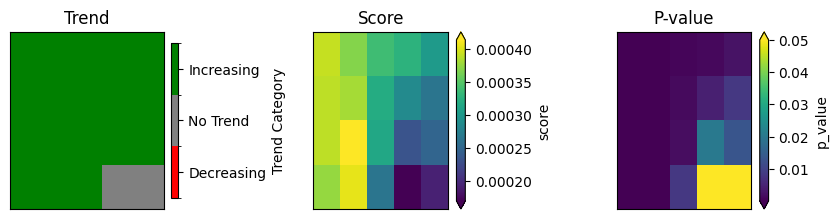

In [39]:
import matplotlib.pyplot as plt
import matplotlib.colors # Import this for colormap and norm
import matplotlib.ticker # Import for colorbar tick formatting

fig, ax = plt.subplots(1,3, figsize = (10,2.3)) # Increased figure width for better spacing
plt.subplots_adjust(wspace=0.8) # Add horizontal space between subplots

# Convert string trends to numerical categories for plotting
# Updated map based on actual pymannkendall output (e.g., 'i' for increasing, 'n' for no trend, 'd' for decreasing)
trend_numeric_map = {
    'n': 0,
    'i': 1,
    'd': -1,
}

# Create a numerical version of change_trend for plotting
# Corrected: Convert to pandas Series before calling .map(), then reshape values
mapped_values = change_trend.astype(str).to_series().map(trend_numeric_map).values
change_trend_numerical = change_trend.copy(data=mapped_values.reshape(change_trend.shape))
change_trend_numerical.name = 'trend' # Keep the name for plotting titles

# Define custom colormap and normalization for categorical data
# Order: decreasing (-1), no trend (0), increasing (1)
cmap_colors = ['red', 'gray', 'green']
cmap = matplotlib.colors.ListedColormap(cmap_colors)
# Define bounds for the numerical categories to map to colors
cmap_bounds = [-1.5, -0.5, 0.5, 1.5] # Bins for -1, 0, 1
norm = matplotlib.colors.BoundaryNorm(cmap_bounds, cmap.N)

# Plot the numerical trend data with a custom colorbar
p0 = change_trend_numerical.plot(x = "x", y = "y", ax = ax[0], cmap=cmap, norm=norm, add_colorbar=False)
ax[0].set_title('Trend')
# Manually add colorbar for categorical data with custom labels
cbar = plt.colorbar(p0, ax=ax[0], ticks=[-1, 0, 1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_ticklabels(['Decreasing', 'No Trend', 'Increasing'])
cbar.set_label('Trend Category')

# Plot score and p-value (these should work as they are float)
change_score.plot(x = "x", y = "y", ax = ax[1], robust = True)
ax[1].set_title('Score')

change_pval.plot(x = "x", y = "y", ax = ax[2], robust = True, vmax = 0.05)
ax[2].set_title('P-value')

for axis in ax:
  axis.set_ylabel("")
  axis.set_xlabel("")
  axis.set_xticks([])
  axis.set_yticks([])

In [35]:
print(f"Unique trend values in change_trend: {np.unique(change_trend.values)}")

Unique trend values in change_trend: ['i' 'n']
